# **Assignment 13 - CNN Classifier for Squat Assessment**

In [31]:
import os
import re
import json
import random
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, roc_auc_score
from itertools import product
from datetime import datetime
import joblib
from torchinfo import summary

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

Using device: mps


In [32]:
def load_csv_files(files, data_dir):
    dataframes = []
    for f in files:
        path = os.path.join(data_dir, f)
        df = pd.read_csv(path)
        df.columns = df.columns.str.strip()
        dataframes.append(df)
    return pd.concat(dataframes, ignore_index=True)

def split_csv_files(datafolder, random_seed, training_prop, validation_prop):
    csv_files = [f for f in os.listdir(datafolder) if f.endswith(".csv")]
    random.seed(random_seed)
    random.shuffle(csv_files)
    train_n = int(len(csv_files) * training_prop)
    val_n = int(len(csv_files) * validation_prop)
    if validation_prop == 0:
        train_files = csv_files[:train_n]
        test_files = csv_files[train_n:]
        return train_files, test_files
    else:
        train_files = csv_files[:train_n]
        val_files = csv_files[train_n:train_n + val_n]
        test_files = csv_files[train_n + val_n:]
        return train_files, val_files, test_files

def select_joints(X, joints):
    selected_cols = []
    for col in X.columns:
        if any(joint in col for joint in joints):
            selected_cols.append(col)
    return X[selected_cols].copy()

def select_every_nth_frame(df, step=3):
    selected_cols = []
    for col in df.columns:
        frame_part = col.split("_")[0]
        frame_idx = int(frame_part.replace("frame", ""))
        if frame_idx % step == 0:
            selected_cols.append(col)
    return df[selected_cols].copy()

def mirror_dataframe(df):
    df_copy = df.copy()
    mirror_pairs = [
        ("left_shoulder", "right_shoulder"),
        ("left_elbow", "right_elbow"),
        ("left_hand", "right_hand"),
        ("left_hip", "right_hip"),
        ("left_knee", "right_knee"),
        ("left_foot", "right_foot"),
    ]
    for col in df.columns:
        parts = col.split("_")
        if len(parts) < 3:
            continue
        frame = parts[0]
        coord = parts[-1]
        joint = "_".join(parts[1:-1])
        for left, right in mirror_pairs:
            if joint == left:
                mirrored_col = f"{frame}_{right}_{coord}"
                if mirrored_col in df.columns:
                    df_copy[col] = df[mirrored_col]
            elif joint == right:
                mirrored_col = f"{frame}_{left}_{coord}"
                if mirrored_col in df.columns:
                    df_copy[col] = df[mirrored_col]
    return df_copy

def reshape_to_cnn_input(x, feature_columns):
    if hasattr(x, 'values'):
        x = x.values
    frame_numbers = sorted(set(int(re.search(r'frame(\d+)_', col).group(1)) for col in feature_columns))
    feature_names = sorted(set(re.sub(r'^frame\d+_', '', col) for col in feature_columns))
    n_samples = x.shape[0]
    n_frames = len(frame_numbers)
    n_features = len(feature_names)
    print(f"Reshaping: {n_samples} samples, {n_frames} frames, {n_features} features")
    col_index = {col: i for i, col in enumerate(feature_columns)}
    x_4d = np.zeros((n_samples, 1, n_frames, n_features))
    for f_idx, frame_num in enumerate(frame_numbers):
        for feat_idx, feat_name in enumerate(feature_names):
            col_name = f"frame{frame_num}_{feat_name}"
            if col_name in col_index:
                x_4d[:, 0, f_idx, feat_idx] = x[:, col_index[col_name]]
    return x_4d, (n_frames, n_features)

In [33]:
def init_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.kaiming_uniform_(m.weight)
        nn.init.zeros_(m.bias)

class SquatClassifierCNN(nn.Module):
    def __init__(self, input_dim, dropout_rate=0.25):
        super().__init__()
        self.input_dim = input_dim
        self.dropout_rate = dropout_rate
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Dropout2d(dropout_rate)
        )
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(32, 16, kernel_size=3, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.conv_block3 = nn.Sequential(
            nn.Conv2d(16, 8, kernel_size=3, padding=2),
            nn.BatchNorm2d(8),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(dropout_rate)
        )
        self._flat_size = self._get_flat_size()
        self.classifier = nn.Sequential(
            nn.Linear(self._flat_size, 32),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(32, 1)
        )
        self.classifier.apply(init_weights)

    def _get_flat_size(self):
        with torch.no_grad():
            dummy = torch.zeros(1, 1, self.input_dim[0], self.input_dim[1])
            x = self.conv_block1(dummy)
            x = self.conv_block2(x)
            x = self.conv_block3(x)
        return x.view(1, -1).shape[1]

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

def build_cnn_model(config, input_dim):
    return SquatClassifierCNN(input_dim=input_dim, dropout_rate=config["dropout"]).to(device)

In [34]:
def compute_metrics(y_true, probs, threshold=0.5):
    preds = (probs >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
    return {
        "tp": int(tp), "fp": int(fp), "tn": int(tn), "fn": int(fn),
        "accuracy": accuracy_score(y_true, preds),
        "precision": precision_score(y_true, preds, zero_division=0),
        "recall": recall_score(y_true, preds, zero_division=0),
        "auc": roc_auc_score(y_true, probs)
    }

def train_one_model(model, config, x_train, y_train, x_val, y_val, loss_fn):
    optimizer = optim.Adam(model.parameters(), lr=config["lr"])
    epochs = config["epochs"]
    best_val_auc = 0
    best_state = None
    patience = 10
    epochs_no_improve = 0
    history = {"train_loss": [], "val_loss": [], "val_auc": []}
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        logits = model(x_train)
        train_loss = loss_fn(logits, y_train)
        train_loss.backward()
        optimizer.step()
        model.eval()
        with torch.no_grad():
            val_logits = model(x_val)
            val_loss = loss_fn(val_logits, y_val)
            probs = torch.sigmoid(val_logits)
            val_auc = roc_auc_score(y_val.cpu().numpy().ravel(), probs.cpu().numpy().ravel())
        history["train_loss"].append(train_loss.item())
        history["val_loss"].append(val_loss.item())
        history["val_auc"].append(val_auc)
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            best_state = model.state_dict().copy()
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
        if epochs_no_improve >= patience:
            break
    if best_state is not None:
        model.load_state_dict(best_state)
    return best_val_auc, model, history

def cross_validate_model(config, X, y, loss_fn, input_dim, n_splits=10):
    kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_SEED)
    fold_auc_scores = []
    for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
        print(f"  Fold {fold + 1}/{n_splits}...")
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
        X_val_tensor = torch.tensor(X_val, dtype=torch.float32).to(device)
        y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).to(device).view(-1, 1)
        y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).to(device).view(-1, 1)
        model = build_cnn_model(config, input_dim)
        val_auc, _, _ = train_one_model(model, config, X_train_tensor, y_train_tensor, X_val_tensor, y_val_tensor, loss_fn)
        fold_auc_scores.append(val_auc)
    return {"cv_mean_auc": np.mean(fold_auc_scores), "auc_std": np.std(fold_auc_scores), "fold_scores": fold_auc_scores}

In [35]:
def load_champion_info(metadata_dir):
    path = os.path.join(metadata_dir, "champion_info.json")
    if not os.path.exists(path):
        return None
    with open(path, "r") as f:
        return json.load(f)

def save_champion_model(champion_dir, metadata_dir, model, model_name, auc, recall, precision, accuracy, hyperparameters):
    torch.save(model.state_dict(), os.path.join(champion_dir, "champion_model.pt"))
    info = {
        "model_name": model_name,
        "saved_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "auc": float(auc),
        "recall": float(recall),
        "precision": float(precision),
        "accuracy": float(accuracy),
        "hyperparameters": hyperparameters
    }
    with open(os.path.join(metadata_dir, "champion_info.json"), "w") as f:
        json.dump(info, f, indent=2)
    print("New champion model saved!")

def update_champion(metadata_dir, champion_dir, model, model_name, auc, recall, precision, accuracy, hyperparameters):
    current = load_champion_info(metadata_dir)
    if current is None:
        print("No champion found --> saving first model")
        save_champion_model(champion_dir, metadata_dir, model, model_name, auc, recall, precision, accuracy, hyperparameters)
    elif auc > current["auc"]:
        print(f"New model is better (auc {auc:.4f} > {current['auc']:.4f})")
        save_champion_model(champion_dir, metadata_dir, model, model_name, auc, recall, precision, accuracy, hyperparameters)
    else:
        print(f"Model NOT better (auc {auc:.4f} <= {current['auc']:.4f})")

In [36]:
data_folder = "../../MainProject/data/mediapipe_bad_good_fixed_c"
training_proportion = 0.7
validation_proportion = 0
train_files, test_files = split_csv_files(data_folder, RANDOM_SEED, training_proportion, validation_proportion)
train_data = load_csv_files(train_files, data_folder)
test_data = load_csv_files(test_files, data_folder)
y_train = train_data["target"]
x_train = train_data.drop(columns="target")
y_test = test_data["target"]
x_test = test_data.drop(columns="target")
useful_joints = ["left_shoulder", "right_shoulder", "left_hip", "right_hip", "left_knee", "right_knee", "left_foot", "right_foot"]
x_train = select_joints(x_train, useful_joints)
x_test = select_joints(x_test, useful_joints)
x_train = select_every_nth_frame(x_train, step=3)
x_test = select_every_nth_frame(x_test, step=3)
print(f"Training data shape: {x_train.shape}")
print(f"Test data shape: {x_test.shape}")
print(f"Training targets shape: {y_train.shape}")
print(f"Test targets shape: {y_test.shape}")

Training data shape: (70, 240)
Test data shape: (30, 240)
Training targets shape: (70,)
Test targets shape: (30,)


## Reverse in time data

In [37]:
scaler = StandardScaler()

feature_columns = x_train.columns.tolist()
x_train_cnn, input_shape = reshape_to_cnn_input(x_train, feature_columns)
x_test_cnn, _ = reshape_to_cnn_input(x_test, feature_columns)


x_train_reverse = x_train_cnn[:, :, ::-1, :]

B, C, T, F = x_train_cnn.shape
x_train_flat = x_train_cnn.reshape(B, -1)
x_test_flat = x_test_cnn.reshape(x_test_cnn.shape[0], -1)

x_train_scaled = scaler.fit_transform(x_train_flat)
x_test_scaled = scaler.transform(x_test_flat)

x_train_cnn = x_train_scaled.reshape(B, C, T, F)
x_test_cnn = x_test_scaled.reshape(x_test_cnn.shape[0], C, T, F)


print(f"CNN input shape: {x_train_cnn.shape}")
print(f"Input dimensions (frames, features): {input_shape}")

Reshaping: 70 samples, 10 frames, 24 features
Reshaping: 30 samples, 10 frames, 24 features
CNN input shape: (70, 1, 10, 24)
Input dimensions (frames, features): (10, 24)


## normal data

In [ ]:

scaler = StandardScaler()

x_train_scaled = pd.DataFrame(scaler.fit_transform(x_train), columns=x_train.columns)
x_test_scaled = pd.DataFrame(scaler.transform(x_test), columns=x_test.columns)

scaler_path = Path("squat_classifier_models/good_vs_bad.joblib")
scaler_path.parent.mkdir(parents=True, exist_ok=True)

scaler_path = "squat_classifier_models/good_vs_bad.joblib"
joblib.dump(scaler, scaler_path)

feature_columns = x_train_scaled.columns.tolist()
x_train_cnn, input_shape = reshape_to_cnn_input(x_train_scaled, feature_columns)
x_test_cnn, _ = reshape_to_cnn_input(x_test_scaled, feature_columns)

print(f"CNN input shape: {x_train_cnn.shape}")
print(f"Input dimensions (frames, features): {input_shape}")



Reshaping: 70 samples, 10 frames, 24 features
Reshaping: 30 samples, 10 frames, 24 features
CNN input shape: (70, 1, 10, 24)
Input dimensions (frames, features): (10, 24)


In [39]:
param_grid = {"lr": [0.001, 0.0005], "dropout": [0.1], "epochs": [50, 100]}
trial = 0
best_auc = 0
best_config = None
loss_func = nn.BCEWithLogitsLoss()
print("Starting Grid Search...")
print("=" * 60)
for values in product(param_grid["lr"], param_grid["dropout"], param_grid["epochs"]):
    config = {"lr": values[0], "dropout": values[1], "epochs": values[2]}
    print(f"\nTrial {trial + 1}: {config}")
    results = cross_validate_model(config, x_train_cnn, y_train, loss_func, input_shape)
    auc_score = results["cv_mean_auc"]
    print(f"  CV mean AUC: {auc_score:.4f} +- {results['auc_std']:.4f}")
    if auc_score > best_auc:
        best_auc = auc_score
        best_config = config
        print(f"  *** NEW BEST! ***")
    trial += 1
print("\n" + "=" * 60)
print(f"Best configuration: {best_config}")
print(f"Best cross-validation AUC: {best_auc:.4f}")

Starting Grid Search...

Trial 1: {'lr': 0.001, 'dropout': 0.1, 'epochs': 50}
  Fold 1/10...
  Fold 2/10...
  Fold 3/10...
  Fold 4/10...
  Fold 5/10...
  Fold 6/10...
  Fold 7/10...
  Fold 8/10...
  Fold 9/10...
  Fold 10/10...
  CV mean AUC: 0.9917 +- 0.0250
  *** NEW BEST! ***

Trial 2: {'lr': 0.001, 'dropout': 0.1, 'epochs': 100}
  Fold 1/10...
  Fold 2/10...
  Fold 3/10...
  Fold 4/10...
  Fold 5/10...
  Fold 6/10...
  Fold 7/10...
  Fold 8/10...
  Fold 9/10...
  Fold 10/10...
  CV mean AUC: 1.0000 +- 0.0000
  *** NEW BEST! ***

Trial 3: {'lr': 0.0005, 'dropout': 0.1, 'epochs': 50}
  Fold 1/10...
  Fold 2/10...
  Fold 3/10...
  Fold 4/10...
  Fold 5/10...
  Fold 6/10...
  Fold 7/10...
  Fold 8/10...
  Fold 9/10...
  Fold 10/10...
  CV mean AUC: 1.0000 +- 0.0000

Trial 4: {'lr': 0.0005, 'dropout': 0.1, 'epochs': 100}
  Fold 1/10...
  Fold 2/10...
  Fold 3/10...
  Fold 4/10...
  Fold 5/10...
  Fold 6/10...
  Fold 7/10...
  Fold 8/10...
  Fold 9/10...
  Fold 10/10...
  CV mean AUC: 0

After augmentation: x_tr shape = (112, 1, 10, 24)
Final model validation AUC: 1.0000


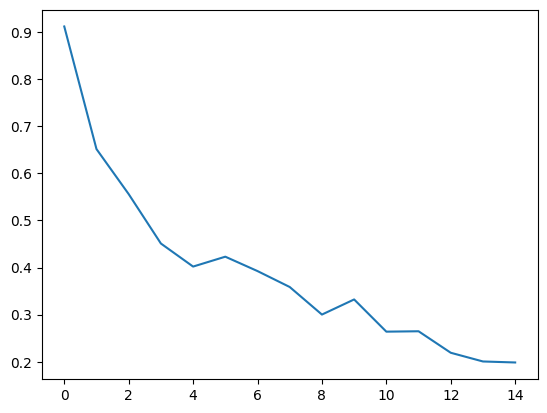

In [40]:
x_tr, x_val, y_tr, y_val = train_test_split(x_train_cnn, y_train, test_size=0.2, random_state=RANDOM_SEED, stratify=y_train)
x_tr_mirror = np.flip(x_tr, axis=2).copy()
x_tr = np.concatenate([x_tr, x_tr_mirror], axis=0)
y_tr = np.concatenate([y_tr, y_tr], axis=0)
print(f"After augmentation: x_tr shape = {x_tr.shape}")
X_tr = torch.tensor(x_tr, dtype=torch.float32).to(device)
Y_tr = torch.tensor(y_tr, dtype=torch.float32).to(device).view(-1, 1)
X_val = torch.tensor(x_val, dtype=torch.float32).to(device)
Y_val = torch.tensor(y_val.values, dtype=torch.float32).to(device).view(-1, 1)
final_model = build_cnn_model(best_config, input_shape)
val_auc, final_model, history = train_one_model(final_model, best_config, X_tr, Y_tr, X_val, Y_val, loss_func)
print(f"Final model validation AUC: {val_auc:.4f}")
summary(final_model, input_size=(1, 1, input_shape[0], input_shape[1]))

plt.plot(history["train_loss"], label="Train Loss")


TEST SET EVALUATION
Test AUC:       1.0000
Accuracy:       0.9667
Precision:      1.0000
Recall:         0.9583


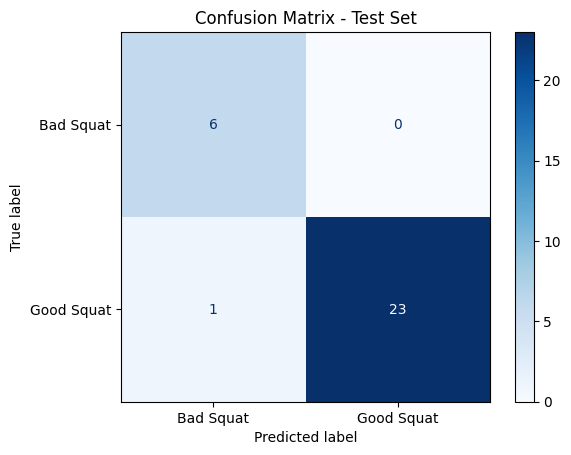

In [41]:
X_test = torch.tensor(x_test_cnn, dtype=torch.float32).to(device)
Y_test = torch.tensor(y_test.values, dtype=torch.float32).to(device).view(-1, 1)
final_model.eval().to(device)
with torch.no_grad():
    logits = final_model(X_test)
    probs = torch.sigmoid(logits)
    y_true = Y_test.cpu().numpy().ravel()
    y_scores = probs.cpu().numpy().ravel()
    metrics = compute_metrics(y_true, y_scores)
print("\n" + "=" * 50)
print("TEST SET EVALUATION")
print("=" * 50)
print(f"Test AUC:       {metrics['auc']:.4f}")
print(f"Accuracy:       {metrics['accuracy']:.4f}")
print(f"Precision:      {metrics['precision']:.4f}")
print(f"Recall:         {metrics['recall']:.4f}")
cm = confusion_matrix(y_true, (y_scores >= 0.5).astype(int))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Bad Squat", "Good Squat"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Test Set")
plt.show()

In [42]:
metadata_dir = "../squat_classifier_models/metadata"
champion_dir = "../squat_classifier_models/champion_model"
os.makedirs(metadata_dir, exist_ok=True)
os.makedirs(champion_dir, exist_ok=True)
update_champion(metadata_dir, champion_dir, final_model, "squat_classifier_cnn", metrics['auc'], metrics['recall'], metrics['precision'], metrics['accuracy'], best_config)
print("Model saved successfully!")

Model NOT better (auc 1.0000 <= 1.0000)
Model saved successfully!


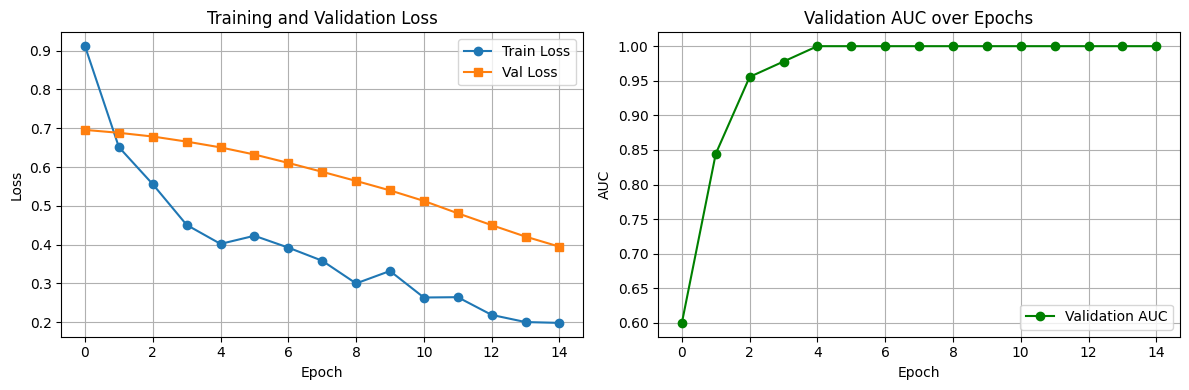

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history["train_loss"], label="Train Loss", marker='o')
axes[0].plot(history["val_loss"], label="Val Loss", marker='s')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training and Validation Loss")
axes[0].legend()
axes[0].grid(True)
axes[1].plot(history["val_auc"], label="Validation AUC", color="green", marker='o')
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("AUC")
axes[1].set_title("Validation AUC over Epochs")
axes[1].legend()
axes[1].grid(True)
plt.tight_layout()
plt.show()